# Collective motion from a custom track format

This notebook does two things at once:

1. **Writes a track converter for a format mosaic does not ship** -- SchoolTracker's
   `_fov.h5` files -- entirely inside the notebook, so you can see every step.
2. **Runs the classic collective-motion measurements** on the result: the
   Tunstrom et al. polarization and rotation order parameters, the collective
   state they define, per-individual local order, and nearest-neighbour
   structure.

If you have your own tracking output in some other format, section 3 is the part
to copy. See [Adding a converter](../docs/adding-a-converter.md) for the full
contract.

## The data

Free-swimming golden shiners (*Notemigonus crysoleucas*), groups of 10, 30, 70
and 151 in a 2.1 x 1.2 m tank, filmed from above and tracked with SchoolTracker.
Each `_fov.h5` also carries a 256-ray visual field per individual, computed with
Fovea. This notebook uses trial `0066` (10 fish, seven ~2 minute segments,
24,578 frames at 29.97 fps -- about 13.7 minutes).

There is no stimulus in this trial. "Collective detection" in the source paper is
a ray-casting measure computed downstream; it is not what this notebook shows.

**Citation.** Davidson JD, Sosna MMG, Twomey CR, Sridhar VH, Leblanc SP, Couzin ID
(2021) Collective detection based on visual information in animal groups.
*Journal of the Royal Society Interface* 18: 20210142.
[doi:10.1098/rsif.2021.0142](https://doi.org/10.1098/rsif.2021.0142)

**Data licence.** CC0 1.0, from Dryad:
[doi:10.5061/dryad.sbcc2fr2h](https://doi.org/10.5061/dryad.sbcc2fr2h). mosaic
ships none of it. To run against the real recording, download `10-fish-0066.zip`
(1.04 GB) and point `DATA_DIR` at the extracted folder. Without it this notebook
generates a synthetic stand-in with the same field layout, so every cell still
runs.

In [1]:
import shutil
import tempfile
from pathlib import Path
from typing import Literal, Optional

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Point this at the extracted 10-fish-0066 folder to use the real recording.
# Left as None, the next cell writes a synthetic stand-in instead.
DATA_DIR: Optional[Path] = None

FPS = 29.97
WORK = Path(tempfile.mkdtemp(prefix="shiners-"))


def write_synthetic_trial(
    out_dir: Path, n_segments: int = 7, per_segment: int = 900, n_tracks: int = 10
) -> None:
    """Write one continuous recording split into `_fov.h5` segments.

    Deliberately faithful to the real dataset in two ways that matter: the
    segments are contiguous in time, and each one relabels its tracks in an
    arbitrary order, so the converter's identity re-linking is exercised here
    too rather than only on the real recording.
    """
    rng = np.random.default_rng(20210142)
    total = n_segments * per_segment
    t = np.arange(total) / FPS
    radius = 260.0 + rng.normal(0, 30, n_tracks)
    phase = rng.uniform(0, 2 * np.pi, n_tracks)
    theta = phase[:, None] + 0.55 * t[None, :] + rng.normal(0, 0.02, (n_tracks, total))
    x = 960.0 + radius[:, None] * np.cos(theta)
    y = 516.0 + radius[:, None] * np.sin(theta)
    heading = theta + np.pi / 2
    hx, hy = np.cos(heading), np.sin(heading)

    arc = np.tile(np.arange(1, 22, dtype=float), (n_tracks, total, 1))
    bend = 0.35 * np.sin(np.linspace(0, np.pi, 21))[None, None, :]
    mid_y_full = np.tile(bend * np.sin(t)[None, :, None], (n_tracks, 1, 1))
    perp_x, perp_y = -hy, hx

    for s in range(n_segments):
        lo, hi = s * per_segment, (s + 1) * per_segment
        order = np.arange(n_tracks) if s == 0 else rng.permutation(n_tracks)
        sl = slice(lo, hi)
        with h5py.File(out_dir / f"0066_{s:03d}_fov.h5", "w") as f:
            f.attrs["nframes"] = np.uint32(per_segment)
            f.attrs["ntracks"] = np.uint32(n_tracks)
            g = f.create_group("fields")
            g["x"], g["y"] = x[order, sl], y[order, sl]
            g["heading_x"], g["heading_y"] = hx[order, sl], hy[order, sl]
            g["body_midline_x"] = arc[order, sl]
            g["body_midline_y"] = mid_y_full[order, sl]
            g["body_length"] = np.full((n_tracks, per_segment), 77.0)
            g["left_eye_x"] = x[order, sl] + 3.0 * perp_x[order, sl]
            g["left_eye_y"] = y[order, sl] + 3.0 * perp_y[order, sl]
            g["right_eye_x"] = x[order, sl] - 3.0 * perp_x[order, sl]
            g["right_eye_y"] = y[order, sl] - 3.0 * perp_y[order, sl]
            g["detected"] = np.ones((n_tracks, per_segment), dtype=np.int8)
            g["version"] = np.bytes_(b"synthetic")


if DATA_DIR is None:
    SRC = WORK / "sim_0066"
    SRC.mkdir(parents=True, exist_ok=True)
    write_synthetic_trial(SRC)
    print(f"synthetic mode: 7 segments written to {SRC}")
else:
    SRC = Path(DATA_DIR)
    print(f"real mode: reading {SRC}")

segments = sorted(p for p in SRC.glob("*_fov.h5") if not p.name.startswith("._"))
print(f"{len(segments)} segments: {[p.name for p in segments]}")

# Where one segment ends and the next begins, in merged frame numbers. Used
# later to check that identity survived the joins.
lengths = []
for seg in segments:
    with h5py.File(seg, "r") as f:
        lengths.append(int(f.attrs["nframes"]))
JOIN_FRAMES = list(np.cumsum(lengths)[:-1])
print(f"{sum(lengths):,} frames total, joins at {JOIN_FRAMES}")

synthetic mode: 7 segments written to /var/folders/sq/f41r2kzn2ngbwmv7p9lqfvp40000gp/T/shiners-_s83kug4/sim_0066
7 segments: ['0066_000_fov.h5', '0066_001_fov.h5', '0066_002_fov.h5', '0066_003_fov.h5', '0066_004_fov.h5', '0066_005_fov.h5', '0066_006_fov.h5']
6,300 frames total, joins at [np.int64(900), np.int64(1800), np.int64(2700), np.int64(3600), np.int64(4500), np.int64(5400)]


## 1. What is in the file

Each segment is one HDF5 file: two root attributes and a flat `fields` group.
Every array is **individual-major**, shaped `(n_tracks, n_frames)` or
`(n_tracks, n_frames, n_points)`.

| Field | Shape | What it is |
| --- | --- | --- |
| `x`, `y` | `(10, 3596)` | the **head** position in video pixels, within 2 px of the eye midpoint |
| `heading_x`, `heading_y` | `(10, 3596)` | a **measured** body-axis unit vector, not a velocity direction |
| `body_midline_x`, `_y` | `(10, 3596, 21)` | the midline in a **body-local** frame, not pixels |
| `body_length` | `(10, 3596)` | pixels; about 77 px here |
| `left_eye_*`, `right_eye_*` | `(10, 3596)` | pixels |
| `detected` | `(10, 3596)` | validity mask; all 1 in this trial |
| `fov_distance`, `fov_identity` | `(10, 3596, 256)` | the 256-ray visual field, unused here |

Two of those rows are the whole reason this converter is interesting.

**The midline is body-local.** `body_midline_x` runs 1.0 to 21.0 -- it is arc
position in units of one midline segment, not a pixel coordinate -- and
`body_midline_y` is the lateral bend in the same units. One unit is
`body_length / 20` pixels, about 3.9 px. Point 0 is the head. To get pixels you
scale, rotate by the heading, and translate to the head position. Dropping the
raw values into `poseX*` would put every keypoint in the top-left corner of the
frame.

Nothing in the file says any of that. It was established by overlaying candidate
reconstructions on the video and keeping the one that lands on fish: of the four
sign conventions, the arc running *against* the heading with the lateral offset
negated sits 35 intensity units below background, against 25 and 9 for the
others. That check is worth running for any format whose geometry is
undocumented, and it takes one frame.

One thing it also shows: at the tracker's own `body_length` the reconstructed
midline spans about 1.5 times the visible fish (median blob extent 53 px against
a reported 77.6). The converter still records 77.6, because a converter's job is
to report what the tracker measured, not to apply a correction nobody can see
later. `midline_scale` is there for a reader who wants keypoints that hug the
pixels.

**The heading is measured, not derived.** It comes from the body-axis fit, and it
is genuinely different from the direction of travel: the two differ by a median
of 3.5 degrees, and by more than 15 degrees on 15 percent of frames. Fish
sideslip, glide, and turn their bodies before their paths follow. Keeping it
matters, and the next section is about what mosaic requires in order to let you.

In [2]:
with h5py.File(segments[0], "r") as f:
    print("attrs:", dict(f.attrs))
    for name, dset in sorted(f["fields"].items()):
        print(f"  {name:22s} {str(dset.shape):18s} {dset.dtype}")

    hx = f["fields/heading_x"][()]
    hy = f["fields/heading_y"][()]
    mx = f["fields/body_midline_x"][()]
    x = f["fields/x"][()]

print(f"\n|heading| min={np.hypot(hx, hy).min():.6f} max={np.hypot(hx, hy).max():.6f}"
      "   <- a unit vector, so no normalization needed")
print(f"body_midline_x range: {mx.min():.2f} .. {mx.max():.2f}"
      "   <- NOT pixels; body-local arc position")
print(f"x range: {x.min():.1f} .. {x.max():.1f}   <- pixels, inside a 1920-wide frame")

attrs: {'nframes': np.uint32(900), 'ntracks': np.uint32(10)}
  body_length            (10, 900)          float64
  body_midline_x         (10, 900, 21)      float64
  body_midline_y         (10, 900, 21)      float64
  detected               (10, 900)          int8
  heading_x              (10, 900)          float64
  heading_y              (10, 900)          float64
  left_eye_x             (10, 900)          float64
  left_eye_y             (10, 900)          float64
  right_eye_x            (10, 900)          float64
  right_eye_y            (10, 900)          float64
  version                ()                 |S9
  x                      (10, 900)          float64
  y                      (10, 900)          float64

|heading| min=1.000000 max=1.000000   <- a unit vector, so no normalization needed
body_midline_x range: 1.00 .. 21.00   <- NOT pixels; body-local arc position
x range: 642.4 .. 1277.6   <- pixels, inside a 1920-wide frame


## 2. What mosaic asks a converter for

A converter turns one raw file into one standard table: per frame, per individual,
with `frame, time, id, group, sequence, X, Y` and at least one `poseX*`/`poseY*`
pair. The `mosaic_v1` schema adds two rules that decide this converter's design.

**Positions are video pixels, and `X`/`Y` is the body centre.** The file gives a
head position, so the converter computes the centre from the reconstructed
midline rather than passing `fields/x` through.

**Derived quantities are forbidden.** `mosaic_v1` refuses fifteen columns --
`VX, VY, AX, AY, SPEED, ANGLE, ANGULAR_V, X#wcentroid` and their variants --
because each one was, at some point, computed *by a converter* and then read
downstream as though the tracker had reported it. Velocity by `np.gradient`,
heading by a principal-component fit whose sign is arbitrary. The numbers look
plausible, so nothing downstream can tell a measurement from a guess. Those
quantities belong to features, where the method is chosen and recorded.

`ANGLE` is on that list -- and SchoolTracker genuinely measures it. That is what
`extends` and `allows` are for: declare a schema that is `mosaic_v1` in every
other respect and lifts exactly one column.

In [3]:
from mosaic.core.schema import TrackSchema, register_track_schema

register_track_schema(
    TrackSchema(
        name="schooltracker_v1",
        extends="mosaic_v1",
        allows={"ANGLE"},
        description=(
            "mosaic_v1 plus the body-axis heading SchoolTracker measures. The "
            "tracker fits a 21-point midline and reports a heading unit vector "
            "per individual per frame; ANGLE is that vector, not an inference "
            "from displacement. Nothing else in the derived set is allowed."
        ),
    )
)

from mosaic.core.schema import TRACK_SCHEMAS, schema_family

s = TRACK_SCHEMAS["schooltracker_v1"]
print("forbidden here :", sorted(s.forbidden))
print("ANGLE allowed  :", "ANGLE" not in s.forbidden)
print("family         :", schema_family("schooltracker_v1"))

forbidden here : ['ANGULAR_A', 'ANGULAR_A#centroid', 'ANGULAR_V', 'ANGULAR_V#centroid', 'AX', 'AY', 'SPEED', 'SPEED#centroid', 'SPEED#pcentroid', 'SPEED#wcentroid', 'VX', 'VY', 'X#wcentroid', 'Y#wcentroid']
ANGLE allowed  : True
family         : mosaic_v1


objc[17452]: Class AVFFrameReceiver is implemented in both /Users/jacob/miniforge3/envs/mosaic/lib/python3.14/site-packages/av/.dylibs/libavdevice.62.3.102.dylib (0x177a403a8) and /Users/jacob/miniforge3/envs/mosaic/lib/python3.14/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x30a6c43a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[17452]: Class AVFAudioReceiver is implemented in both /Users/jacob/miniforge3/envs/mosaic/lib/python3.14/site-packages/av/.dylibs/libavdevice.62.3.102.dylib (0x177a403f8) and /Users/jacob/miniforge3/envs/mosaic/lib/python3.14/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x30a6c43f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


`allows` only takes effect together with `extends` -- it subtracts from the
forbidden set the base contributed. A schema that declares `forbidden=` and
`allows=` with no `extends` registers without complaint and still refuses the
column.

Note the family: `schooltracker_v1` resolves to `mosaic_v1`, so these tables mix
freely with any other pixel-native table in the same feature run.

**One caveat, because this schema is registered in a notebook rather than in
mosaic.** The schema *name* is recorded in `tracks/index.csv`, and validation
runs on the write path. Conversion therefore has to happen in a process that
registered it -- this notebook. Feature runs in a fresh process are fine, but
`mosaic convert` from the command line would not know the name. For a
self-contained analysis that is the right trade; a converter used across a team
belongs in a module everyone imports.

## 3. The converter

Four class variables, a `Params` model, and one `convert` method.

In [4]:
from scipy.optimize import linear_sum_assignment

from mosaic.core.track_converter import (
    EntryHints,
    TrackConverter,
    TrackConvertParams,
    register_track_converter,
)

class SchoolTrackerParams(TrackConvertParams):
    """Everything that determines the output -- and nothing else.

    Entry identity (which group, which sequence) travels in `EntryHints`, never
    here: params are hashed into the tracks variant id, so a sequence name in
    params would mint one variant per file where there is one recipe.

    Annotations are written out in full rather than behind a type alias. A
    pydantic model resolves a string annotation against its defining module, and
    a notebook cell does not always give it one, so an alias can leave the model
    "not fully defined" at the first call.
    """

    fps: float = 29.97
    keypoints: Literal["landmarks", "midline"] = "midline"
    drop_undetected: bool = True
    midline_scale: float = 1.0


@register_track_converter
class SchoolTrackerConverter(TrackConverter[SchoolTrackerParams]):
    """SchoolTracker + Fovea `_fov.h5` -> a `schooltracker_v1` table.

    Keypoint layout, `keypoints="midline"`: `poseX0..poseX20` are the 21 midline
    points from head (0) to tail (20). Under `keypoints="landmarks"`: 0 head,
    1 left eye, 2 right eye, 3 tail. Keypoint identity is positional and is
    recorded nowhere on disk, so this docstring is the only mapping there is.

    `midline_scale` defaults to 1.0, which reconstructs the midline at the
    `body_length` the tracker reports. Measured against the video, that spans
    about 1.5 times the visible fish -- the blob extent along the body axis has
    a median of 53 px where `body_length` reads 77.6. The converter records the
    tracker's own number rather than a correction factor, so the discrepancy
    stays visible and the choice stays the reader's.
    """

    src_format = "schooltracker_fov_h5"
    version = "0.1"
    enumerable = False          # no file holds more than one sequence
    merges_per_sequence = True  # ... but seven files hold one between them
    output_schema = "schooltracker_v1"
    Params = SchoolTrackerParams

    def sequence_from_stem(self, stem: str) -> str:
        """`0066_003_fov` -> `0066`: the trial, not the segment.

        This is what makes the scan group the seven files into one entry. It
        describes the format's naming, so it is not a `Params` field.
        """
        return stem.split("_")[0]

    def convert(
        self, path: Path, params: SchoolTrackerParams, hints: EntryHints
    ) -> pd.DataFrame:
        with h5py.File(path, "r") as f:
            n_frames = int(f.attrs["nframes"])
            n_tracks = int(f.attrs["ntracks"])
            read = lambda name: f[f"fields/{name}"][()]  # noqa: E731
            hx, hy = read("heading_x"), read("heading_y")
            head_x, head_y = read("x"), read("y")
            mid_x, mid_y = read("body_midline_x"), read("body_midline_y")
            body_length = read("body_length")
            left_x, left_y = read("left_eye_x"), read("left_eye_y")
            right_x, right_y = read("right_eye_x"), read("right_eye_y")
            detected = read("detected")

        pose_x, pose_y = self._midline_to_pixels(
            mid_x, mid_y, body_length * params.midline_scale, head_x, head_y, hx, hy
        )

        # The seven files are one recording, so this segment's frames continue
        # where the previous one stopped, and its track labels are mapped back
        # onto the first segment's.
        offset, canonical = self._segment_offsets(path, n_tracks)
        frames = offset + np.tile(np.arange(n_frames, dtype=np.int64), n_tracks)
        columns: dict[str, np.ndarray] = {
            "frame": frames,
            "time": frames / params.fps,
            "id": np.repeat(canonical.astype(np.int64), n_frames),
            # mosaic_v1 wants the body centre; the file gives a head position.
            "X": pose_x.mean(axis=2).reshape(-1),
            "Y": pose_y.mean(axis=2).reshape(-1),
            "ANGLE": np.arctan2(hy, hx).reshape(-1),
            "body_length": body_length.reshape(-1),
            "group": np.full(frames.size, hints.group),
            "sequence": np.full(frames.size, hints.sequence or path.stem),
        }

        if params.keypoints == "midline":
            points = [(pose_x[:, :, k], pose_y[:, :, k]) for k in range(pose_x.shape[2])]
        else:
            points = [
                (head_x, head_y),
                (left_x, left_y),
                (right_x, right_y),
                (pose_x[:, :, -1], pose_y[:, :, -1]),
            ]
        for k, (kx, ky) in enumerate(points):
            columns[f"poseX{k}"] = kx.reshape(-1)
            columns[f"poseY{k}"] = ky.reshape(-1)

        table = pd.DataFrame(columns)
        if params.drop_undetected:
            table = table[detected.reshape(-1) != 0].reset_index(drop=True)
        return table

    @staticmethod
    def _siblings(path: Path) -> list[Path]:
        """This trial's segments, in recording order."""
        trial = path.name.split("_")[0]
        return sorted(
            p
            for p in path.parent.glob(f"{trial}_*_fov.h5")
            if not p.name.startswith("._")  # AppleDouble files on a Mac volume
        )

    @staticmethod
    def _edge(path: Path, index: int) -> np.ndarray:
        """Every individual's position on one frame, as an (n, 2) array."""
        with h5py.File(path, "r") as f:
            return np.stack([f["fields/x"][:, index], f["fields/y"][:, index]], axis=-1)

    @classmethod
    def _segment_offsets(cls, path: Path, n_tracks: int) -> tuple[int, np.ndarray]:
        """This segment's starting frame, and its track labels in trial terms.

        The seven files of a trial are consecutive chunks of one recording, but
        each one numbers its frames from zero and labels its tracks in an
        arbitrary order. Concatenating them raw would give every individual a
        trajectory that teleports at all six joins.

        Frames are fixed by summing the earlier segments' `nframes`. Identity is
        fixed by matching each segment's first frame to the previous segment's
        last, which is a 1/30 s gap: the assignment sits 3-7 px away while the
        next-best candidate is 33-56 px away, so it is not a close call. The
        per-join permutations compose forward, mapping this segment's labels
        onto segment 000's.

        This is the one place the converter opens a file other than the one it
        was handed. It reads two columns per sibling, not the arrays.
        """
        siblings = cls._siblings(path)
        try:
            position = siblings.index(path)
        except ValueError as exc:  # pragma: no cover - a path outside its own glob
            msg = f"{path.name} is not among the segments globbed beside it"
            raise ValueError(msg) from exc

        offset = 0
        canonical = np.arange(n_tracks)
        for earlier, later in zip(siblings[:position], siblings[1 : position + 1]):
            with h5py.File(earlier, "r") as f:
                offset += int(f.attrs["nframes"])
            cost = np.linalg.norm(
                cls._edge(later, 0)[:, None, :] - cls._edge(earlier, -1)[None, :, :],
                axis=-1,
            )
            rows, cols = linear_sum_assignment(cost)
            step = np.empty(n_tracks, dtype=int)
            step[rows] = cols
            canonical = canonical[step]
        return offset, canonical

    @staticmethod
    def _midline_to_pixels(
        mid_x: np.ndarray,
        mid_y: np.ndarray,
        body_length: np.ndarray,
        head_x: np.ndarray,
        head_y: np.ndarray,
        hx: np.ndarray,
        hy: np.ndarray,
    ) -> tuple[np.ndarray, np.ndarray]:
        """Body-local midline -> image pixels.

        `mid_x` is arc position in midline-segment units and `mid_y` the lateral
        bend in the same units, so one unit is `body_length / span` pixels. The
        arc runs from the head backwards, against the heading.
        """
        span = mid_x[:, :, -1:] - mid_x[:, :, :1]
        scale = body_length[:, :, None] / span
        arc = (mid_x - mid_x[:, :, :1]) * scale
        lateral = mid_y * scale
        ux, uy = hx[:, :, None], hy[:, :, None]
        pixel_x = head_x[:, :, None] - arc * ux + lateral * uy
        pixel_y = head_y[:, :, None] - arc * uy - lateral * ux
        return pixel_x, pixel_y


print("registered as:", SchoolTrackerConverter.src_format)

registered as: schooltracker_fov_h5


### Seven files, one sequence

The seven files are consecutive two-minute chunks of one continuous recording.
They should be analyzed as one trial, and `merges_per_sequence = True` plus
`sequence_from_stem` is how a converter says so: the scan groups the files whose
stems share a trial into one entry, converts each, and concatenates them.

Two things have to be repaired for that concatenation to mean anything, and the
converter does both.

**Frames restart at zero in every file.** Concatenating raw would give seven
frames numbered 0, and any windowed feature would read them as simultaneous. Each
segment's frames are offset by the total of the segments before it.

**Track labels are permuted at every join.** This is the one that bites quietly.
Matching each segment's first frame to the previous segment's last gives a
genuine permutation, never the identity, at all six joins -- `id 3` in one file is
not `id 3` in the next. Concatenating raw would give every individual a
trajectory that teleports six times.

Be precise about what that costs, because it is less than it sounds and the
difference is instructive. Every measurement in this notebook is computed *within
a frame* -- polarization, rotation, local order, nearest-neighbour distance -- and
none of them care which fish is which, so all of them survive a scrambled
identity unchanged. What does not survive is anything that differences an
individual *across* frames: speed and velocity, turning rate, `trajectory-smooth`,
`temporal-stack`, any windowed or `overlap_frames` feature, and the velocity
fallback `heading_source="auto"` would use on a table without `ANGLE`. Those are
the reason to repair identity rather than shrug at it.

The repair is cheap because the gap between segments is a frame or two: the
matched partner sits 3 to 7 px away while the next-best candidate is 33 to 56 px
away. That is a factor of ten, not a judgement call, so a linear-sum assignment
recovers the permutation exactly and the per-join permutations compose forward
onto segment 000's labels.

The cell after the conversion checks the result rather than asserting it. A
mislinked track would teleport, so it compares the per-frame step on the six join
frames against every other frame. The joins do come out larger -- a few frames are
dropped at each segment boundary, so a fish really has moved further -- but the
largest step at any join stays below the largest step elsewhere, which is what
rules out a swap.

Worth being explicit that this is a property of *this* dataset, not a general
recipe. A recording where individuals leave and re-enter, or where the gap
between files is long enough for the shoal to reorganize, has no such margin, and
the honest answer there is one sequence per file.

## 4. Build the dataset and convert

In [5]:
from mosaic.core.dataset import Dataset, new_dataset_manifest
from mosaic.core.manifest import TracksScanSource, default_roots
from mosaic.core.pipeline.tracks_index import read_tracks_index

DS_DIR = WORK / "shiners_project"
if DS_DIR.exists():
    shutil.rmtree(DS_DIR)

ds = Dataset(
    new_dataset_manifest(name="shiners 0066", base_dir=DS_DIR, roots=dict(default_roots))
).load()

ds.add_scan_source(
    TracksScanSource(
        id="shiners",
        path=str(SRC),
        patterns=("*_fov.h5",),
        src_format="schooltracker_fov_h5",
    )
)

ds.scan_tracks()
print(f"raw files indexed: {len(ds.read_tracks_raw_index())}")

outcome = ds.convert_all_tracks(params={"fps": FPS, "keypoints": "midline"})
print(outcome)
assert outcome.failed == 0, "a file failed to convert"

read_tracks_index(ds)[["sequence", "run_id", "std_format", "n_rows"]]

[index_tracks_raw] 7 -> /private/var/folders/sq/f41r2kzn2ngbwmv7p9lqfvp40000gp/T/shiners-_s83kug4/shiners_project/tracks_raw/index.csv
raw files indexed: 7
ConversionOutcome(converted=1, failed=0)


,sequence,run_id,std_format,n_rows
0,0066,convert-schooltracker_fov_h5.0.1-7fd30cfd3d,schooltracker_v1,63000


## 5. Look at the tracks before trusting any number

A converter that transposes an axis, or reconstructs the midline in the wrong
direction, produces a table that passes every schema check and is entirely wrong.
Plotting one frame is the cheapest way to catch it: the midlines should sit on
the fish, and every heading arrow should point along its own body, from tail to
head.

0066: 63,000 rows, frames 0-6299, 10 individuals
step at the 6 joins : median  6.75 px, max  22.94 px
step everywhere else : median  6.50 px, max  42.76 px
21 keypoints, in order: ['poseX0', 'poseX1', 'poseX2', 'poseX3'] ... poseX20


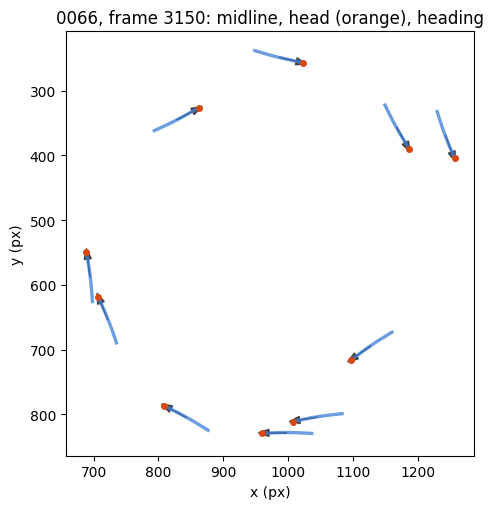

In [6]:
from mosaic.core.pipeline.loading import pose_column_pairs

first = read_tracks_index(ds).iloc[0]
grp, seq = str(first["group"]), str(first["sequence"])
tracks = ds.load_tracks(grp, seq)
print(f"{seq}: {len(tracks):,} rows, frames {tracks.frame.min()}-{tracks.frame.max()}, "
      f"{tracks.id.nunique()} individuals")

# Did the identity re-linking hold? A mislinked track teleports across a join,
# so compare the per-frame step on the join frames against every other frame.
# An absolute threshold would not do -- what makes a teleport a teleport is that
# it is unlike the fish's own motion.
ordered = tracks.sort_values(["id", "frame"])
step = np.hypot(ordered.groupby("id").X.diff(), ordered.groupby("id").Y.diff())
at_join = step[ordered.frame.isin(JOIN_FRAMES)]
elsewhere = step[~ordered.frame.isin(JOIN_FRAMES)]
print(f"step at the {len(JOIN_FRAMES)} joins : median {at_join.median():5.2f} px, "
      f"max {at_join.max():6.2f} px")
print(f"step everywhere else : median {elsewhere.median():5.2f} px, "
      f"max {elsewhere.max():6.2f} px")

pairs = pose_column_pairs(tracks.columns)
print(f"{len(pairs)} keypoints, in order: {[x for x, _ in pairs][:4]} ... {pairs[-1][0]}")

# A concrete frame, not frame.median() -- an even frame count makes that a
# half-integer that matches no row, and the plot silently comes out empty.
frame_no = int(tracks.frame.quantile(0.5, interpolation="nearest"))
snapshot = tracks[tracks.frame == frame_no]

fig, ax = plt.subplots(figsize=(9, 5.2))
for _, fish in snapshot.iterrows():
    px = [fish[xc] for xc, _ in pairs]
    py = [fish[yc] for _, yc in pairs]
    ax.plot(px, py, "-", lw=2.4, alpha=0.75, color="#3b7dd8")
    ax.plot(px[0], py[0], "o", ms=4, color="#d9480f")  # head
    ax.arrow(
        fish["X"], fish["Y"],
        44 * np.cos(fish["ANGLE"]), 44 * np.sin(fish["ANGLE"]),
        head_width=11, length_includes_head=True, color="#2b2b2b", alpha=0.8,
    )
ax.set_aspect("equal")
ax.invert_yaxis()  # image coordinates: +Y points down
ax.set(xlabel="x (px)", ylabel="y (px)",
       title=f"{seq}, frame {frame_no}: midline, head (orange), heading")
fig.tight_layout()

## 6. Collective motion

Two order parameters, from Tunstrom et al. (2013). With `u_i` the unit heading of
individual `i` and `r_i` the unit vector from the group centroid to it:

- **polarization** `O_p = |mean(u_i)|` -- how aligned the group is, 0 to 1.
- **rotation** `O_r = |mean(u_i x r_i)|` -- how much it circles its own centre.

High polarization and low rotation is a **polarized** school; the reverse is a
**mill**; both low is a disordered **swarm**.

`heading_source="auto"` uses `ANGLE` when the table carries a usable one and
falls back to the direction of travel otherwise. Here it should resolve to
`orientation` -- and the output records which, so the choice is auditable rather
than assumed.

[feature:collective-motion-metrics__from__tracks] completed run_id=0.1-7022d787be -> /private/var/folders/sq/f41r2kzn2ngbwmv7p9lqfvp40000gp/T/shiners-_s83kug4/shiners_project/features/collective-motion-metrics__from__tracks/0.1-7022d787be
heading_source: <ArrowStringArray>
['orientation']
Length: 1, dtype: str  <- 'orientation' means ANGLE was used
6,300 frames  |  polarization 0.144  rotation 0.983


[collective-motion-metrics__from__tracks] Processed 1/1 sequences


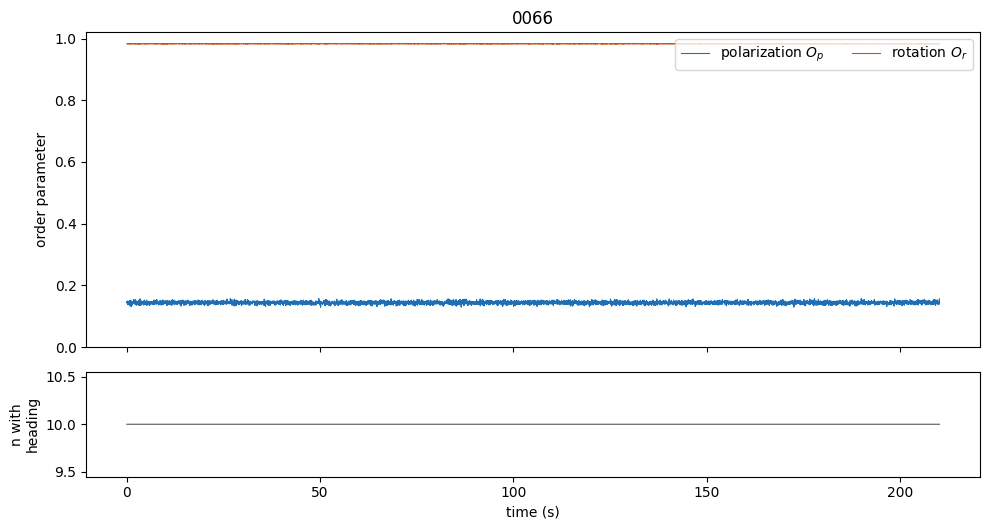

In [7]:
from mosaic.behavior.feature_library.collective_motion_metrics import CollectiveMotionMetrics

cmm = ds.run_feature(CollectiveMotionMetrics(params={"fps": FPS}))


def read_feature(result) -> pd.DataFrame:
    """Concatenate a feature run's per-sequence parquet outputs."""
    run_dir = ds.get_root("features") / result.feature / result.run_id
    return pd.concat(
        [pd.read_parquet(p) for p in sorted(run_dir.glob("*.parquet"))],
        ignore_index=True,
    )


group = read_feature(cmm)
print("heading_source:", group.heading_source.unique(), " <- 'orientation' means ANGLE was used")
print(f"{len(group):,} frames  |  polarization {group.polarization.mean():.3f}"
      f"  rotation {group.rotation.mean():.3f}")

one = group[group.sequence == seq].sort_values("frame")
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(10, 5.4), sharex=True,
                              gridspec_kw={"height_ratios": [3, 1]})
ax.plot(one.time, one.polarization, lw=0.8, label="polarization $O_p$", color="#1f6fb4")
ax.plot(one.time, one.rotation, lw=0.8, label="rotation $O_r$", color="#c9541a")
ax.set(ylabel="order parameter", ylim=(0, 1.02), title=f"{seq}")
ax.legend(loc="upper right", ncols=2)
ax2.plot(one.time, one.n_ids_heading, lw=0.8, color="#555")
ax2.set(xlabel="time (s)", ylabel="n with\nheading")
fig.tight_layout()

`n_ids_heading` is the divisor of the order parameters -- the number of
individuals that actually contributed. It is the first thing to check when a
value looks surprising: a shoal that drops to two tracked fish will report a
confident polarization computed from almost nothing.

### Smoothing changes the answer

The state thresholds (0.35 and 0.65) sit on top of quantities whose per-frame
variance goes as 1/N. With ten fish that variance is large, so classifying each
raw frame and classifying a smoothed signal give visibly different answers.
mosaic deliberately has no smoothing parameter: smoothing is a choice about the
*series*, made here where you can see it, rather than folded into the feature.

,per frame,smoothed (30 frames)
Polarized,0.0,0.00
Milling,100.0,99.54
Swarm,0.0,0.00
Transitional,0.0,0.00
Undefined,0.0,0.46


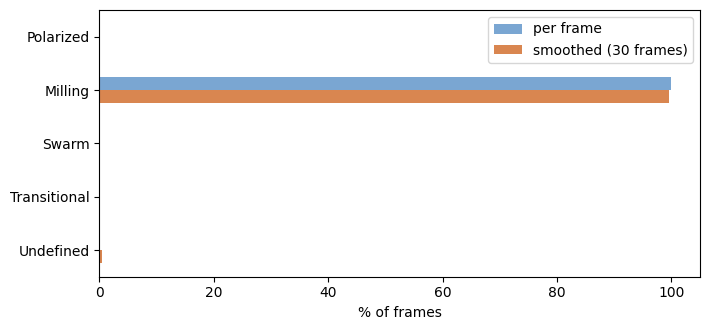

In [8]:
from mosaic.behavior.feature_library.collective_math import classify_state

window = int(round(FPS))  # a one-second moving average

smoothed = []
for _, sub in group.groupby("sequence", sort=True):
    sub = sub.sort_values("frame")
    pol = sub.polarization.rolling(window, center=True).mean().to_numpy()
    rot = sub.rotation.rolling(window, center=True).mean().to_numpy()
    smoothed.append(pd.Series(classify_state(rot, pol)))
smoothed_state = pd.concat(smoothed, ignore_index=True)

order = ["Polarized", "Milling", "Swarm", "Transitional", "Undefined"]
table = pd.DataFrame({
    "per frame": group.state.value_counts(normalize=True) * 100,
    f"smoothed ({window} frames)": smoothed_state.value_counts(normalize=True) * 100,
}).reindex(order).fillna(0.0).round(2)
display(table)

fig, ax = plt.subplots(figsize=(7.2, 3.4))
table.plot.barh(ax=ax, color=["#7aa6d2", "#d98650"])
ax.set(xlabel="% of frames", ylabel="")
ax.invert_yaxis()
ax.legend(title="")
fig.tight_layout()

In [23]:
filename = '/Volumes/JD-SSD/CollectiveDetection_Shiners_Data/savedresults-final/data-grid.pklz'

In [24]:
import pickle, gzip
with gzip.open(filename, 'rb') as f: 
    data = pickle.load(f)

In [26]:
data[0]

[array([[-108.95093388,  -27.8636207 ,   21.174256  , ...,   67.86334425,
          102.97588517,   61.6374999 ],
        [-108.90278078,  -28.75161868,   21.42023487, ...,   66.99466062,
          102.91135864,   62.3840928 ],
        [-116.38093052,  -25.19532496,   23.79133625, ...,   69.46023507,
          104.11210772,   61.953677  ],
        ...,
        [-170.79626184,  -53.33934438,    5.53670614, ...,   -4.32236816,
           61.22730478,   38.7460578 ],
        [-164.50627474,  -53.25994726,    3.91464959, ...,   -5.64824059,
           62.02938281,   38.37251436],
        [-155.14708743,  -51.41335826,    0.77245044, ...,   -8.18579554,
           63.04288999,   37.59829328]], shape=(24578, 10)),
 array([[-61.28186635,  13.6940325 ,  45.84776483, ...,  10.61755696,
         -25.07957527, -26.74656902],
        [-59.90696489,  13.56497919,  46.93965635, ...,   9.9199325 ,
         -24.30832812, -27.63914984],
        [-57.06081358,  13.37829893,  48.26893058, ...,   9.301958

### The state space

Plotting rotation against polarization directly is the clearest single view of
what the group did. The thresholds cut it into the named states.

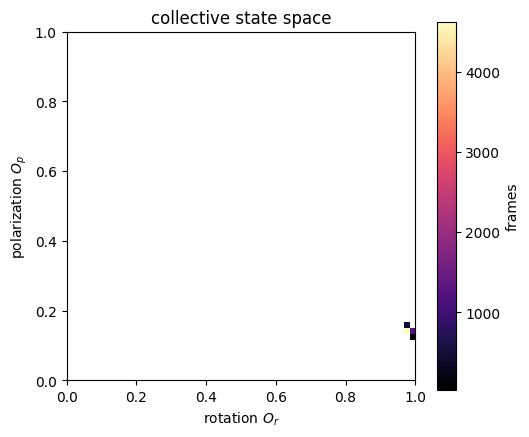

In [9]:
from mosaic.behavior.feature_library.collective_math import STATE_HIGH, STATE_LOW

fig, ax = plt.subplots(figsize=(5.4, 5))
h = ax.hist2d(group.rotation, group.polarization, bins=60,
              range=[[0, 1], [0, 1]], cmap="magma", cmin=1)
for level in (STATE_LOW, STATE_HIGH):
    ax.axhline(level, color="w", lw=0.8, ls="--", alpha=0.7)
    ax.axvline(level, color="w", lw=0.8, ls="--", alpha=0.7)
ax.set(xlabel="rotation $O_r$", ylabel="polarization $O_p$",
       title="collective state space", aspect="equal")
fig.colorbar(h[3], ax=ax, label="frames", shrink=0.82)
fig.tight_layout()

## 7. Local order, per individual

The same two order parameters restricted to a disc around each fish. `radius` is
required and has no default on purpose: it is in position units -- pixels here --
and a defaulted radius would produce a full, entirely wrong table on a dataset at
a different scale. This file carries `body_length`, so the radius can be stated
in body lengths and converted.

Say which body length you mean. On the real recording `body_length` reads about
1.5 times the visible fish, so three of them is nearer four and a half fish. That
is not a reason to fudge the column -- it is a reason to write the factor down
where a reader of the figure can see it.

reported body length 77.0 px -> radius 231.0 px
[feature:local-order-metrics__from__tracks] completed run_id=0.1-60024c52d4 -> /private/var/folders/sq/f41r2kzn2ngbwmv7p9lqfvp40000gp/T/shiners-_s83kug4/shiners_project/features/local-order-metrics__from__tracks/0.1-60024c52d4


[local-order-metrics__from__tracks] Processed 1/1 sequences


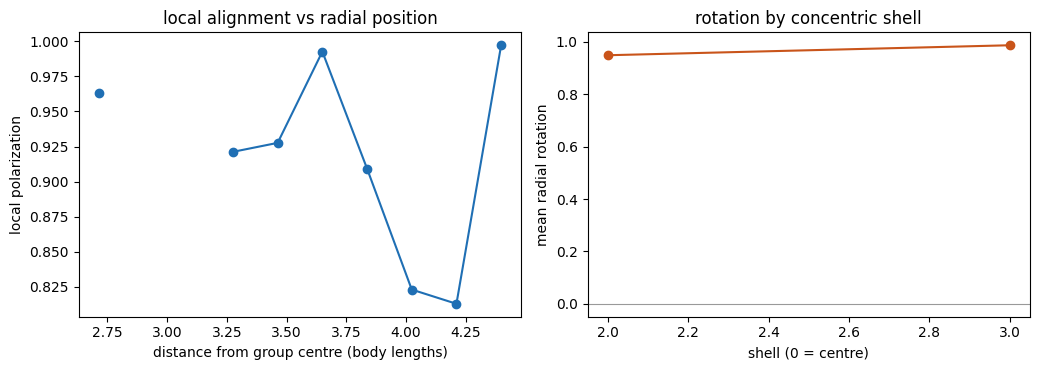

In [10]:
from mosaic.behavior.feature_library.local_order_metrics import LocalOrderMetrics

body_length_px = float(tracks.body_length.median())
radius_px = 3.0 * body_length_px
print(f"reported body length {body_length_px:.1f} px -> radius {radius_px:.1f} px")

lom = ds.run_feature(LocalOrderMetrics(params={"radius": radius_px, "n_shells": 4}))
local = read_feature(lom)

valid = local[local.n_local_neighbors >= 0]
bins = np.linspace(0, valid.dist_to_group_center.quantile(0.99), 25)
mids = 0.5 * (bins[1:] + bins[:-1])
# observed=False keeps empty bins as NaN, so the profile stays aligned with
# `mids`. With observed=True an empty bin is dropped and the two lengths differ.
profile = valid.groupby(
    pd.cut(valid.dist_to_group_center, bins), observed=False
).local_polarization.mean()

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.8))
ax.plot(mids / body_length_px, profile.to_numpy(), "o-", color="#1f6fb4")
ax.set(xlabel="distance from group centre (body lengths)",
       ylabel="local polarization", title="local alignment vs radial position")
shells = local.drop_duplicates(["sequence", "frame", "shell_index"])
shells = shells[shells.shell_index >= 0]
ax2.plot(shells.groupby("shell_index").shell_radial_rotation.mean(), "o-", color="#c9541a")
ax2.axhline(0, color="#999", lw=0.8)
ax2.set(xlabel="shell (0 = centre)", ylabel="mean radial rotation",
        title="rotation by concentric shell")
fig.tight_layout()

## 8. Neighbour structure

`nearest-neighbour` gives, per individual per frame, the identity, distance and
relative position of the closest other fish -- the last of these both in the world
frame and rotated into the focal fish's own frame. The egocentric offsets are
what the classic neighbour-density heatmap is made of, and they are only
meaningful because the table carries a real `ANGLE`.

[nearest-neighbor__from__tracks] Processed 1/1 sequences


[feature:nearest-neighbor__from__tracks] completed run_id=0.2-2d470c9573 -> /private/var/folders/sq/f41r2kzn2ngbwmv7p9lqfvp40000gp/T/shiners-_s83kug4/shiners_project/features/nearest-neighbor__from__tracks/0.2-2d470c9573
median nearest-neighbour distance: 75.8 px = 0.98 reported body lengths


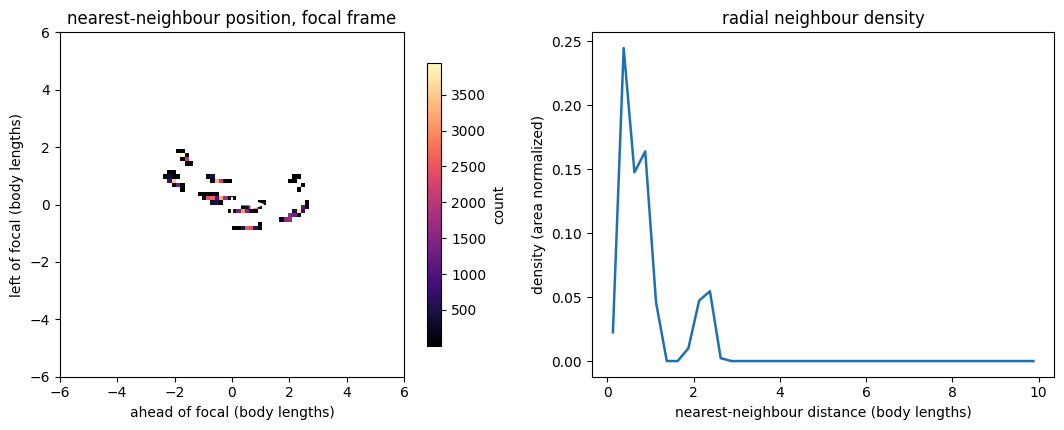

In [11]:
from mosaic.behavior.feature_library.nearestneighbor import NearestNeighbor

nn = read_feature(ds.run_feature(NearestNeighbor()))
bl = body_length_px

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))

lim = 6.0  # body lengths
h = ax.hist2d(nn.nn_delta_x_ego / bl, nn.nn_delta_y_ego / bl, bins=80,
              range=[[-lim, lim], [-lim, lim]], cmap="magma", cmin=1)
ax.plot(0, 0, "w+", ms=11, mew=1.6)
ax.arrow(0, 0, 1.1, 0, head_width=0.28, color="w", length_includes_head=True)
ax.set(xlabel="ahead of focal (body lengths)", ylabel="left of focal (body lengths)",
       title="nearest-neighbour position, focal frame", aspect="equal")
fig.colorbar(h[3], ax=ax, label="count", shrink=0.82)

edges = np.linspace(0, 10, 41)
counts, _ = np.histogram(nn.nn_dist.dropna() / bl, bins=edges)
shell_area = np.pi * (edges[1:] ** 2 - edges[:-1] ** 2)
ax2.plot(0.5 * (edges[1:] + edges[:-1]), counts / shell_area / counts.sum(),
         "-", lw=1.8, color="#1f6fb4")
ax2.set(xlabel="nearest-neighbour distance (body lengths)",
        ylabel="density (area normalized)", title="radial neighbour density")
fig.tight_layout()

print(f"median nearest-neighbour distance: {nn.nn_dist.median():.1f} px "
      f"= {nn.nn_dist.median() / bl:.2f} reported body lengths")

## 9. Using this for your own data

Cells 2, 4 and the converter are format-specific. Everything from section 4
onwards is not -- it runs on any schema-valid track table, whatever produced it.

To adapt the converter, answer three questions:

1. **Does one file hold many sequences, or do many files make one sequence?**
   Set `enumerable = True` and implement `enumerate_sequences`, or
   `merges_per_sequence = True` and override `sequence_from_stem`. They are
   mutually exclusive.
2. **Does your tracker measure anything `mosaic_v1` forbids?** If it genuinely
   reports a heading or a speed, declare a schema that `extends="mosaic_v1"` and
   `allows` exactly that column. If it does not, emit `mosaic_v1` and let the
   features derive it -- that is the honest answer, and the one that records how
   the derivation was done.
3. **Are your coordinates already video pixels?** `mosaic_v1` says they are. If
   yours are physical units or re-centred, convert in the converter and say so in
   its docstring, or the numbers will be wrong by a factor nobody recorded.

[Adding a converter](../docs/adding-a-converter.md) covers the full contract,
including how to ship a converter inside mosaic rather than in a notebook, and
what the registry tests check for you once you do.